# <center><u><b>L'analyse de performance e-commerce — TheLook Europe</b></u></center>


# <b>Contexte</b>

Vous assumez la position d'Analyste de données chez « TheLook Europe ». L'équipe du commerce électronique vous sollicite pour examiner la performance de l'activité dans un cadre spécifique et pour établir une comparaison entre l'année 2023 et l'année 2024. Votre tâche consiste à analyser les dynamiques de chiffre d'affaires, de marge, de retours et de comportement du client, puis à communiquer des conclusions claires à travers un tableau de bord Power BI.


# <b>L'objectif</b>

L'objectif de cette analyse est d'étudier les performances e-commerce du département Women en France entre 2023 et 2024.

Nous allons :

- contrôler la qualité des données,
- réaliser une analyse exploratoire,
- calculer les KPI business,
- comparer les performances 2023 vs 2024,
- identifier des recommandations business.


# <b>Le périmètre  d'étude</b>

| Paramètre | Valeur |
|---|---|
| Pays | France |
| Département | Women |
| Période | 01/01/2023 → 31/12/2024 |
| Source | `thelook_fr_women_2023_2024.csv` |
| Statut vente | `item_status = 'Complete'` |
| Statut retour | `item_status = 'Returned'` |


# <b>Les KPI à calculer</b>

| KPI | Définition |
|---|---|
| Chiffre d'affaires | `SUM(sale_price)` sur les lignes Complete |
| Marge brute | `SUM(sale_price - cost)` sur les lignes Complete |
| Panier moyen | CA / nombre de commandes distinctes (Complete) |
| Taux de retour | Returned / (Complete + Returned) × 100 |
| Taux de ré-achat | Clients avec ≥ 2 commandes Complete sur une même année / total clients actifs × 100 |


# <b>La source</b>

Fichier CSV extrait : `thelook_fr_women_2023_2024`

# 1. Configuration de l'environnement

### 1.1. Import des librairies

In [64]:
# Import des librairies avec leurs alias standard
import pandas as pd                 # Manipulation des données
import numpy as np                  # Calculs Numériques
import matplotlib.pyplot as plt     # Création des graphiques
import seaborn as sns               # Graphiques statistiques avancés

# Vérification des versions
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Seaborn version: {sns.__version__}")
print(f"Matplotlib version: {plt.matplotlib.__version__}")

# Configuration de l'affichage pandas
# display.max_columns=None   : affiche toutes les colonnes sans troncatu
# display.max_rows=100       : limite l'affichage à 100 lignes maximum
# display.precision=2        : limite l'affichage des décimales à 2 chiffres
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.precision', 2)

Pandas version: 2.3.3
NumPy version: 2.4.4
Seaborn version: 0.13.2
Matplotlib version: 3.10.8


# 2. Importation du Dataset

### 2.1 Chargement du Dataset

In [65]:
# Import du dataset
df = pd.read_csv('/Users/ko/Documents/thelook-da-projet-soutenance/thelook-da-projet/data/thelook_fr_women_2023_2024.csv', encoding="utf-8")

# Afficher les dimensions du dataset
print(f"Dimensions du dataset : {df.shape[0]} lignes x {df.shape[1]} colonnes")

# Afficher 5 lignes aléatoires du dataset
df.sample(5)


Dimensions du dataset : 1679 lignes x 20 colonnes


,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
691,85914,124795,4329,2023-12-25 05:56:21+00:00,Shipped,47.99,24.57,Jeans,Women,Levi's,Levi's Women's Plus-Size 580 Defined Waist Boo...,Shipped,2023-12-25 06:47:00+00:00,2023-12-27 22:22:00+00:00,NaN,68627,F,France,Occitanie,Saint-Estève
581,41246,59884,13145,2023-11-11 12:33:05+00:00,Processing,40.99,17.09,Swim,Women,Roxy,Roxy Women's Wave Wanderer Poncho,Processing,2023-11-11 14:37:00+00:00,NaN,NaN,33117,F,France,Hauts-de-France,Bury
633,45001,65379,7189,2023-12-06 23:09:34+00:00,Complete,13.99,6.27,Skirts,Women,ADAR UNIFORMS,Adar Mid-Calf Length Drawstring Skirt,Complete,2023-12-04 00:40:00+00:00,2023-12-05 19:41:00+00:00,2023-12-07 01:01:00+00:00,36125,F,France,Hauts-de-France,Marcq-en-Barœul
375,25107,36443,15879,2023-08-01 06:22:44+00:00,Processing,12.99,6.98,Plus,Women,TrendsBlue,Premium Oversize Large Solid Color Soft Square...,Processing,2023-08-01 08:49:00+00:00,NaN,NaN,20204,F,France,Île-de-France,Montfermeil
1434,88175,128151,6092,2024-10-18 15:26:52+00:00,Complete,9.99,6.44,Leggings,Women,Angelina,Opaque Coffee Brown Stretchy Leotard Leggings ...,Complete,2024-10-14 16:33:00+00:00,2024-10-17 15:09:00+00:00,2024-10-21 01:43:00+00:00,70407,F,France,Île-de-France,Saint-Brice-sous-Forêt


### 2.2 Aperçu de la structure du dataset

In [66]:
# Affichage des informations complètes du Dataset
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          1679 non-null   int64  
 1   order_item_id     1679 non-null   int64  
 2   product_id        1679 non-null   int64  
 3   item_created_at   1679 non-null   object 
 4   item_status       1679 non-null   object 
 5   sale_price        1679 non-null   float64
 6   cost              1679 non-null   float64
 7   category          1679 non-null   object 
 8   department        1679 non-null   object 
 9   brand             1677 non-null   object 
 10  product_name      1679 non-null   object 
 11  order_status      1679 non-null   object 
 12  order_created_at  1679 non-null   object 
 13  shipped_at        1133 non-null   object 
 14  delivered_at      636 non-null    object 
 15  user_id           1679 non-null   int64  
 16  gender            1679 non-null   object 


In [67]:
# Statistiques descriptives des colonnes numériques
df.describe(include='all')

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city
count,1679.00,1679.00,1679.00,1679,1679,1679.00,1679.00,1679,1679,1677,1679,1679,1679,1133,636,1679.00,1679,1679,1679,1679
unique,NaN,NaN,NaN,1679,5,NaN,NaN,22,1,657,1559,5,1117,747,416,NaN,1,1,13,547
top,NaN,NaN,NaN,2023-01-01 06:18:03+00:00,Shipped,NaN,NaN,Intimates,Women,Allegra K,Shadowline Short Robe,Shipped,2023-10-09 09:00:00+00:00,2024-02-04 14:10:00+00:00,2023-10-03 22:56:00+00:00,NaN,F,France,Île-de-France,Paris
freq,NaN,NaN,NaN,1,497,NaN,NaN,247,1679,101,3,497,4,4,4,NaN,1679,1679,397,94
mean,60851.68,88372.70,7922.51,NaN,NaN,57.02,27.46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48702.84,NaN,NaN,NaN,NaN
std,35655.50,51820.58,4680.55,NaN,NaN,69.68,31.85,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28441.85,NaN,NaN,NaN,NaN
min,359.00,517.00,12.00,NaN,NaN,1.82,0.75,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,279.00,NaN,NaN,NaN,NaN
25%,30357.00,44069.50,3812.00,NaN,NaN,19.99,9.68,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,24349.00,NaN,NaN,NaN,NaN
50%,60827.00,88353.00,7907.00,NaN,NaN,38.00,18.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,48715.00,NaN,NaN,NaN,NaN
75%,90911.00,132106.00,12053.00,NaN,NaN,68.00,33.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72541.00,NaN,NaN,NaN,NaN


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Analyse du describe :

#### Analyse de la catégorie "Intimates" :

- La catégorie *Intimates* apparaît comme la catégorie la plus représentée du dataset. Une hypothèse métier plausible est que ce type de produit bénéficie d'une fréquence d'achat plus élevée que d'autres catégories textile, notamment en raison de besoins de renouvellement réguliers.

#### Analyse des prix de vente :

- Le prix de vente moyen des produits est d'environ 57 €, tandis que la médiane est de 38 €. L'écart important entre la moyenne et la médiane suggère une distribution asymétrique à droite, probablement influencée par quelques produits à forte valeur (max observé : 903 €).

#### Analyse des coûts produits :

- Le coût moyen (~27 €) reste inférieur au prix moyen de vente (~57 €). Cette structure est cohérente avec un modèle économique e-commerce reposant sur une marge commerciale positive.

#### Analyse des statuts de commande :

- Le dataset contient 5 statuts différents. Il sera important de bien définir les statuts utilisés dans les KPI : **"Complete"** pour les ventes finalisées, **"Returned"** pour les retours produits.

#### Analyse des valeurs manquantes :

- Les colonnes `shipped_at` et `delivered_at` présentent un volume important de valeurs manquantes. Ces absences sont cohérentes avec le cycle opérationnel des commandes (annulées, retournées, en cours).
</details>

### 2.3 Dictionnaire des données

Le dictionnaire de données permet de comprendre rapidement le rôle de chaque colonne, vérifier les types de données et faciliter la lecture du projet. C'est une bonne pratique pour documenter et sécuriser l'analyse.

| Colonne | Type | Description | Exemple |
|---|---|---|---|
| order_id | int64 | Identifiant de commande | 19425 |
| order_item_id | int64 | Identifiant unique de ligne produit | 28112 |
| product_id | int64 | Identifiant produit | 6983 |
| item_created_at | datetime | Date de création de la ligne produit | 2023-01-01 06:18:03 |
| item_status | object | Statut de la ligne produit | Complete |
| sale_price | float64 | Prix de vente TTC du produit | 29.50 |
| cost | float64 | Coût du produit | 16.05 |
| category | object | Catégorie produit | Shorts |
| department | object | Département produit | Women |
| brand | object | Marque produit | Fox |
| product_name | object | Nom du produit | Fox Juniors Momentum Short |
| order_status | object | Statut global de la commande | Shipped |
| order_created_at | datetime | Date de création de la commande | 2023-01-03 |
| shipped_at | datetime | Date d'expédition | 2023-01-05 |
| delivered_at | datetime | Date de livraison | 2023-01-09 |
| user_id | int64 | Identifiant client | 15644 |
| gender | object | Genre du client | F |
| country | object | Pays du client | France |
| state | object | Région du client | Île-de-France |
| city | object | Ville du client | Paris |

# 3. Contrôle de qualité des données

### 3.1 Création d'une copie de travail du dataset

In [68]:
'''
Création d'une copie du dataset original.
Cela permet de conserver les données brutes intactes en cas d'erreur
pendant le nettoyage ou les transformations.
On travaillera uniquement sur cette copie pour sécuriser l'analyse.
'''

# Création de la copie du dataset
df_clean = df.copy()

print("Copie créée avec succès.")
print(f"Dimensions : {df_clean.shape[0]} lignes x {df_clean.shape[1]} colonnes")

Copie créée avec succès.
Dimensions : 1679 lignes x 20 colonnes


### 3.2 Traitement des valeurs manquantes

In [69]:
# Nombre de valeurs manquantes par colonne
nbr_nan = df_clean.isna().sum()

# Affichage
nbr_nan

order_id               0
order_item_id          0
product_id             0
item_created_at        0
item_status            0
sale_price             0
cost                   0
category               0
department             0
brand                  2
product_name           0
order_status           0
order_created_at       0
shipped_at           546
delivered_at        1043
user_id                0
gender                 0
country                0
state                  0
city                   0
dtype: int64

In [70]:
# Pourcentage de valeurs manquantes par colonne
pourcent_nan = (df_clean.isna().sum() / len(df_clean)) * 100 

# Affichage 
pourcent_nan

order_id             0.00
order_item_id        0.00
product_id           0.00
item_created_at      0.00
item_status          0.00
sale_price           0.00
cost                 0.00
category             0.00
department           0.00
brand                0.12
product_name         0.00
order_status         0.00
order_created_at     0.00
shipped_at          32.52
delivered_at        62.12
user_id              0.00
gender               0.00
country              0.00
state                0.00
city                 0.00
dtype: float64

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- Les colonnes `shipped_at` et `delivered_at` présentent un nombre important de valeurs manquantes. Cela peut signifier que la commande a été annulée, retournée ou n'a pas encore été expédiée.

- Ces valeurs manquantes sont cohérentes avec le cycle de vie d'une commande e-commerce. On ne les supprime pas.

- Les valeurs manquantes dans la colonne `brand` seront remplacées par "Unknown" pour conserver les lignes dans les analyses.
</details>

#### 3.2.1 Imputation des valeurs manquants pour la colonne brand

In [71]:
# Imputation des valeurs manquantes par "Unknown" pour la colonne brand
# Cela permet de conserver les lignes concernées dans les analyses
# tout en gardant une catégorie identifiable
df_clean['brand'] = df_clean['brand'].fillna('Unknown')

# Vérification : plus aucune valeur manquante dans brand
print(f"Valeurs manquantes dans brand : {df_clean['brand'].isna().sum()}")

Valeurs manquantes dans brand : 0


#### 3.2.2 Vérification de la colonne item_status

In [72]:
# Affichage des statuts uniques des lignes produits
df_clean['item_status'].unique()

array(['Shipped', 'Complete', 'Processing', 'Returned', 'Cancelled'],
      dtype=object)

In [73]:
# Pourcentage des statuts
df_clean['item_status'].value_counts(normalize=True) * 100

item_status
Shipped       29.60
Complete      25.31
Processing    18.23
Cancelled     14.29
Returned      12.57
Name: proportion, dtype: float64

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- On observe 5 statuts différents. Une part importante des commandes est expédiée ou reçue, mais une part non négligeable est encore en cours ou annulée.

- **Convention du projet** : on utilisera uniquement `Complete` pour les ventes et `Returned` pour les retours dans les calculs de KPI.
</details

#### 3.2.3 Vérification de la colonne shipped_at et de la colonne delivered_at

In [74]:
# Vérifier les statuts associés aux valeurs manquantes de shipped_at
print("Statuts pour les valeurs manquantes de shipped_at")
print(df_clean[df_clean['shipped_at'].isna()]['order_status'].value_counts())

print()

# Vérifier les statuts associés aux valeurs manquantes de delivered_at
print("Statuts pour les valeurs manquantes de delivered_at")
print(df_clean[df_clean['delivered_at'].isna()]['order_status'].value_counts())

Statuts pour les valeurs manquantes de shipped_at
order_status
Processing    306
Cancelled     240
Name: count, dtype: int64

Statuts pour les valeurs manquantes de delivered_at
order_status
Shipped       497
Processing    306
Cancelled     240
Name: count, dtype: int64


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- Les valeurs manquantes de `shipped_at` correspondent principalement aux statuts `Processing` et `Cancelled` : cohérent, ces commandes n'ont pas encore été envoyées.

- Les valeurs manquantes de `delivered_at` correspondent aux statuts `Processing`, `Cancelled` et `Shipped` : cohérent, ces commandes ne sont pas encore livrées.

- Ces valeurs manquantes sont structurelles et ne traduisent pas un problème de qualité des données.
</details>

### 3.3 Traitement des doublons

#### 3.3.1 Identification des vrais doublons

In [75]:
''' 
Comme nous l'avons vu dans le cours, la méthode duplicated() permet d'identifier les doublons. 
Nous avons obtenu comme résultat que toutes les lignes ont la valeur False, ce peut signifier qu'il n'y a pas de doublon 
et que les lignes du jeu de donnée fournis ne sont pas dupliqué sur l'ensemble des colonnes.
'''

# Comptage des lignes intégralement dupliquées
nombre_doublons = df_clean.duplicated().sum()
print(f"Il y a {nombre_doublons} ligne(s) intégralement dupliquée(s)")

Il y a 0 ligne(s) intégralement dupliquée(s)


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- Aucun doublon intégral détecté. Chaque ligne correspond à une ligne de commande unique.

### Conclusion :

- Cela renforce la fiabilité des calculs de KPI futurs.
</details>

#### 3.3.2 Traitement des faux doublons

In [76]:
'''
Test sur la colonne order_item_id
'''

# Vérification : order_item_id doit être unique (identifiant de ligne produit)
doublons_item_id = df_clean.duplicated(subset=['order_item_id']).sum()
print(f"Doublons sur order_item_id : {doublons_item_id}")

Doublons sur order_item_id : 0


In [77]:
'''
Test sur les colonnes order_id et product_id
'''

# Vérification : un même produit ne doit pas apparaître deux fois dans la même commande
doublons_order_product = df_clean.duplicated(subset=['order_id', 'product_id']).sum()
print(f"Doublons sur order_id & product_id : {doublons_order_product}")

Doublons sur order_id & product_id : 0


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- Aucun doublon sur `order_item_id` : chaque ligne de commande est unique.

- Aucun doublon sur `order_id + product_id` : chaque produit n'apparaît qu'une seule fois par commande.

- L'intégrité des données est confirmée. Les KPI (CA, marge, taux de retour) seront calculés sur des données fiables.
</details>

# 4. Conversion des données

### 4.1 Conversion des dates

In [78]:
'''  
Conversion des colonnes au format datetime
Cela permet à Python de reconnaître les colonnes comme des dates
pour pouvoir faire des analyses temporelles (année, mois ou les délais par exemple)
'''

#  Conversion des colonnes au format datetime
df_clean['item_created_at'] = pd.to_datetime(df_clean['item_created_at'])
df_clean['order_created_at'] = pd.to_datetime(df_clean['order_created_at'])
df_clean['shipped_at'] = pd.to_datetime(df_clean['shipped_at'])
df_clean['delivered_at'] = pd.to_datetime(df_clean['delivered_at'])

# Vérification des types de données
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1679 entries, 0 to 1678
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype              
---  ------            --------------  -----              
 0   order_id          1679 non-null   int64              
 1   order_item_id     1679 non-null   int64              
 2   product_id        1679 non-null   int64              
 3   item_created_at   1679 non-null   datetime64[ns, UTC]
 4   item_status       1679 non-null   object             
 5   sale_price        1679 non-null   float64            
 6   cost              1679 non-null   float64            
 7   category          1679 non-null   object             
 8   department        1679 non-null   object             
 9   brand             1679 non-null   object             
 10  product_name      1679 non-null   object             
 11  order_status      1679 non-null   object             
 12  order_created_at  1679 non-null   datetime64[ns, UTC]
 13  shi

### 4.2 Création des variables temporelles

In [79]:
# Création des colonnes year et month à partir de item_created_at
# Cela simplifiera toutes les analyses temporelles qui suivent
df_clean['year']  = df_clean['item_created_at'].dt.year
df_clean['month'] = df_clean['item_created_at'].dt.month

# Affichage de 5 lignes aléatoires pour vérification
df_clean.sample(5)

,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city,year,month
1549,32865,47678,1145,2024-11-22 07:25:56+00:00,Processing,49.99,21.50,Sweaters,Women,Elan,Elan Hooded Cardigan,Processing,2024-11-22 10:06:00+00:00,NaT,NaT,26381,F,France,Occitanie,Toulouse,2024,11
1440,46212,67148,4795,2024-10-21 14:22:34+00:00,Complete,189.00,110.75,Jeans,Women,PAIGE,PAIGE Women's Skyline Boot Jean,Complete,2024-10-21 15:53:00+00:00,2024-10-23 22:22:00+00:00,2024-10-24 20:32:00+00:00,37084,F,France,Île-de-France,Draveil,2024,10
79,94025,136631,12041,2023-02-19 16:07:17+00:00,Complete,51.00,28.66,Intimates,Women,What Katie Did,What Katie Did Harlow Vintage Peach Deep Suspe...,Complete,2023-02-19 16:35:00+00:00,2023-02-22 08:48:00+00:00,2023-02-24 17:41:00+00:00,75084,F,France,Auvergne-Rhône-Alpes,Thonon-les-Bains,2023,2
398,36721,53299,7288,2023-08-13 11:10:29+00:00,Cancelled,16.99,6.15,Skirts,Women,Full Tilt,FULL TILT Houndstooth Bodycon Skirt,Cancelled,2023-08-12 12:46:00+00:00,NaT,NaT,29465,F,France,Provence-Alpes-Côte d'Azur,Marseille,2023,8
1386,61310,89038,7681,2024-10-01 11:59:56+00:00,Returned,77.00,25.56,Blazers & Jackets,Women,BB Dakota,BB Dakota Yellow Marigold Naples Boxy Cropped ...,Returned,2024-09-30 12:37:00+00:00,2024-09-30 13:16:00+00:00,2024-10-02 22:31:00+00:00,49101,F,France,Auvergne-Rhône-Alpes,Montluel,2024,10


### 4.3 Vérification de la période temporelle

In [80]:
'''
On s'assure que toutes les dates sont bien dans la période 2023-2024
L'énoncé demande explicitement cette vérification.
'''

# Vérification des bornes temporelles
print(f"Date minimum : {df_clean['item_created_at'].min()}")
print(f"Date maximum : {df_clean['item_created_at'].max()}")
print()
print("Les données doivent couvrir du 01/01/2023 au 31/12/2024")

Date minimum : 2023-01-01 06:18:03+00:00
Date maximum : 2024-12-31 10:40:48+00:00

Les données doivent couvrir du 01/01/2023 au 31/12/2024


<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observation :

- Les données couvrent bien la période demandée : du 01/01/2023 au 31/12/2024.

- Cette étape garantit la cohérence du sous-périmètre d'analyse demandé par la direction e-commerce.
</details>

### 4.4  Définition du périmètre ventes

In [81]:
# Convention du projet : item_status == "Complete" = vente finalisée
# On crée df_sales une seule fois ici pour éviter les redéfinitions
# dans les sections suivantes

# Filtre des ventes complètes
df_sales = df_clean[df_clean['item_status'] == 'Complete'].copy()

# Afficher les dimensions du dataset filtré
print(f"Dimensions du dataset ventes : {df_sales.shape[0]} lignes x {df_sales.shape[1]} colonnes")

# Affichage de 5 lignes aléatoires
df_sales.sample(5)

Dimensions du dataset ventes : 425 lignes x 22 colonnes


,order_id,order_item_id,product_id,item_created_at,item_status,sale_price,cost,category,department,brand,product_name,order_status,order_created_at,shipped_at,delivered_at,user_id,gender,country,state,city,year,month
1364,6853,9842,982,2024-09-25 13:44:00+00:00,Complete,36.00,16.70,Sweaters,Women,Wool Overs,Womens Lambswool Turtle Neck Sweater,Complete,2024-09-25 16:34:00+00:00,2024-09-26 16:44:00+00:00,2024-09-30 02:42:00+00:00,5643,F,France,Auvergne-Rhône-Alpes,Lyon,2024,9
367,73170,106258,5588,2023-07-27 01:28:50+00:00,Complete,37.93,19.57,Pants & Capris,Women,Briggs,Briggs New York Women's Petite Ponte Inset Pant,Complete,2023-07-27 05:17:00+00:00,2023-07-27 12:15:00+00:00,2023-07-30 15:04:00+00:00,58562,F,France,Nouvelle-Aquitaine,Saint-Pée-sur-Nivelle,2023,7
901,35460,51459,1410,2024-04-01 14:31:34+00:00,Complete,16.90,7.13,Sweaters,Women,Anna-Kaci,Anna-Kaci S/M Fit Blue and Caf?Mocha Stripes S...,Complete,2024-03-30 15:39:00+00:00,2024-03-31 10:48:00+00:00,2024-04-01 18:04:00+00:00,28490,F,France,Auvergne-Rhône-Alpes,Viuz-en-Sallaz,2024,4
1661,26560,38538,15616,2024-12-27 04:27:59+00:00,Complete,34.00,18.36,Plus,Women,Vanity Fair,Vanity Fair Women's Body Sleeks Age Defying Li...,Complete,2024-12-27 05:27:00+00:00,2024-12-28 21:46:00+00:00,2025-01-02 00:39:00+00:00,21365,F,France,Bourgogne-Franche-Comté,Belfort,2024,12
566,99373,144349,13220,2023-11-02 15:13:36+00:00,Complete,54.99,21.17,Swim,Women,Speedo,Womens One Piece Speedo Sports Swimsuit Plum T...,Complete,2023-10-31 16:32:00+00:00,2023-11-01 17:09:00+00:00,2023-11-03 22:34:00+00:00,79437,F,France,Nouvelle-Aquitaine,Léogeats,2023,11


# 5. Analyse Exploratoire (EDA)

### 5.1 Distribution du prix de vente

#### 5.1.1 Statistiques descriptives

In [82]:
# Statistiques descriptives du prix de vente 
# On utilise df_sales : uniquement les ventes finalisées
df_sales["sale_price"].describe()

count    425.00
mean      55.35
std       71.41
min        1.82
25%       18.97
50%       36.29
75%       62.36
max      903.00
Name: sale_price, dtype: float64

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- Les prix de vente présentent une forte dispersion et une distribution asymétrique à droite, avec quelques produits très coûteux qui influencent la moyenne.

- On observe des produits très accessibles, mais aussi des produits premium avec un prix maximum à 903 €.

### Conclusion :

-  On peut supposer que le catalogue semble combiner une offre majoritairement accessible avec un nombre limité de produits premium, traduisant un positionnement sur plusieurs segments de marché.
</details>

#### 5.1.2 Graphe Distribution du prix 

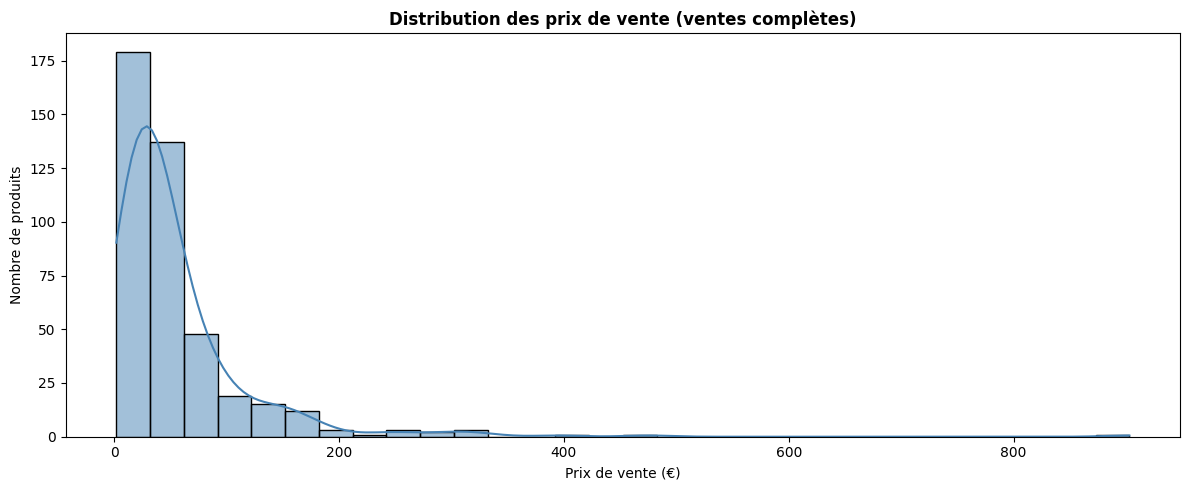

In [83]:
# Taille du graphique
plt.figure(figsize=(12, 5))

# Création de l'histogramme avec courbe de densité
sns.histplot(
    data=df_sales,
    x="sale_price",
    bins=30,
    kde=True,
    color="steelblue"
)

# Ajour du titre
plt.title("Distribution des prix de vente (ventes complètes)", fontsize=12, fontweight='bold')

# Ajout des labels des axes
plt.xlabel("Prix de vente (€)")
plt.ylabel("Nombre de produits")

# Mise en page automatique
plt.tight_layout()

# Affichage du graphe
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations:

- La distribution des prix de vente présente une forte asymétrie à droite : la majorité des produits sont vendus à des prix relativement faibles, tandis qu'un nombre limité de produits affiche des prix très élevés.

- La concentration des ventes se situe principalement entre 0 € et 60 €, ce qui indique que la majorité du catalogue appartient à une gamme de prix accessible.

- La présence d'une longue traîne vers les prix élevés révèle l'existence de produits premium, avec un prix maximum observé de 903 €.

- La moyenne des prix (≈ 57 €) est supérieure à la médiane (≈ 38 €). Cet écart confirme l'influence des produits les plus chers sur la moyenne.

- Dans ce contexte, la médiane apparaît comme un indicateur plus représentatif du prix de vente typique que la moyenne.

### Conclusion:

- Les ventes sont majoritairement concentrées sur des produits à faible ou moyen prix, tandis qu'une faible proportion de produits premium génère une dispersion importante des prix. 

- La distribution n'étant pas symétrique, la médiane constitue une mesure de tendance centrale plus pertinente que la moyenne pour décrire le comportement général des ventes.
</details>

### 5.2 Distribution du coût produit

#### 5.2.1 Statistiques descriptives

In [84]:
# Statistiques descriptives du coût
df_sales["cost"].describe()

count    425.00
mean      26.62
std       33.70
min        0.75
25%        8.74
50%       17.97
75%       29.58
max      437.05
Name: cost, dtype: float64

#### 5.2.2 Détection des valeurs aberrantes sur les coûts

In [85]:
# Calcul des quartiles Q1 et Q3
Q1 = df_sales["cost"].quantile(0.25)
Q3 = df_sales["cost"].quantile(0.75)

# Calcul de l'écart interquartile (IQR)
IQR = Q3 - Q1

# Définition des bornes hautes et basses
limite_inferieure = Q1 - 1.5 * IQR
limite_superieure = Q3 + 1.5 * IQR

# Détection des valeurs aberrantes
masque_outliers = (
    (df_sales["cost"] < limite_inferieure) |
    (df_sales["cost"] > limite_superieure)
)

# Extraction des outliers
outliers = df_sales.loc[masque_outliers]

# Affichage du nombre d'outliers
print(f"Nombre d'outliers détectés : {len(outliers)}")

# Affichage des 10 produits avec les coûts les plus élevés
outliers[[
    "product_name",
    "brand",
    "category",
    "sale_price",
    "cost"
]].sort_values(by="cost", ascending=False).head(10)

Nombre d'outliers détectés : 41


,product_name,brand,category,sale_price,cost
468,The North Face Denali Down Womens Jacket 2013,The North Face,Outerwear & Coats,903.00,437.05
1442,Arc'teryx Women's Beta AR Jacket,Arc'teryx,Outerwear & Coats,475.00,205.20
509,Rebecca Taylor Women's Lace Dress,Rebecca Taylor,Dresses,395.00,179.33
1097,BGSD Women's New Zealand Lambskin Leather Walk...,BGSD,Outerwear & Coats,319.99,144.64
429,Women's The North Face Half Dome Hoodie Sweats...,The North Face,Active,308.00,144.45
1646,True Religion Women's Tony Pony Express Slim Jean,True Religion,Jeans,235.00,132.54
880,Jones New York Walker Leather Jacket,Jones New York,Outerwear & Coats,299.99,127.80
1053,McGinn Women's Clara Textured Blazer,McGinn,Blazers & Jackets,330.00,126.72
679,Trina Turk Women's Elizabeth Toggle Coat,Trina Turk,Outerwear & Coats,290.28,119.60
1260,Pendleton The Portland Collection Women's Coos...,Pendleton,Sweaters,264.67,112.75


### 5.2.3 Graphique de distribution des coûts

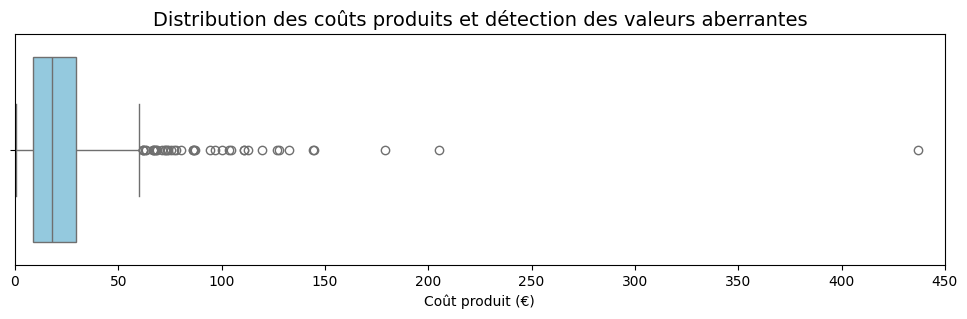

In [86]:
# Création de la taille de la figure 
plt.figure(figsize=(12,3))

# Création du graphique
sns.boxplot(
    data=df_sales,
    x="cost",
    color="skyblue"
)

# Ajout du titre
plt.title(
    "Distribution des coûts produits et détection des valeurs aberrantes",
    fontsize=14,
)

# Zoom sur les valeurs principales
plt.xlim(0, 450)

# Ajout du Label des axes
plt.xlabel("Coût produit (€)")

# Affichage du graphique
plt.show()

<details>
<summary><font size="3" color="#ff7373"><b>Cliquez pour afficher les constats</b></font></summary>

### Observations :

- La majorité des coûts produits est concentrée sur des montants relativement faibles, tandis qu'une minorité de références présente des coûts significativement plus élevés.

- Le boxplot révèle la présence de nombreuses valeurs atypiques au-delà du troisième quartile, traduisant une forte dispersion sur la partie haute de la distribution.

- Ces valeurs extrêmes sont vraisemblablement liées à des produits à forte valeur ajoutée plutôt qu'à des anomalies de collecte.

- Aucune suppression n'est effectuée à ce stade, les outliers étant considérés comme pertinents d'un point de vue métier et susceptibles d'avoir un impact significatif sur l'analyse des marges et du chiffre d'affaires.
</details>